# DA-03 Transaction ↔ Receipt ↔ Trace / Transfer Binding

## 분석 목적

Ethereum Transaction 레코드만으로 실제 실행 결과와 가치이동을 완전히 설명할 수 있는지 검증한다.

DA-01에서 `Transaction Record != Execution Result`를 확인했다면,
DA-03에서는 Transaction을 Receipt, Trace, Token Transfer까지 연결하여
실제 실행 Evidence Chain이 어떻게 구성되는지 분석한다.

특히 Transaction의 `value = 0`인 거래가 실제로 아무 가치이동도 없는 거래인지,
아니면 Contract Execution, Internal ETH Transfer, Token Transfer가 발생한 거래인지 확인한다.

## 검증 질문

1. Transaction과 Receipt는 transaction_hash 기준으로 얼마나 안정적으로 연결되는가?
2. 성공/실패 Transaction에서 Trace 발생 구조는 어떻게 다른가?
3. `transaction.value = 0` 거래에서도 Trace 기반 내부 ETH 이동이 존재하는가?
4. `transaction.value = 0` 거래에서도 Token Transfer가 존재하는가?
5. Transaction 단일 레코드만으로 최종 실행 및 가치이동을 판정할 수 있는가?

## FPG 설계 연결

FPG는 외부 실행 요청의 Transaction 제출 사실만 저장해서는 안 된다.

최종 Audit Evidence는 최소한

Transaction
→ Receipt
→ Execution Trace / Transfer
→ Final Execution State

관계를 동일한 transaction_hash 기준으로 연결할 수 있어야 한다.

In [1]:
import pandas as pd
import numpy as np

FILE_PATH = r"C:\Users\user\Downloads\da_master_transaction_sample_73410 - 복사본.csv"

df = pd.read_csv(FILE_PATH)

print("전체 거래:", len(df))
print("\n컬럼:")
print(df.columns.tolist())

print("\n데이터 타입:")
display(df.dtypes.to_frame("dtype"))

print("\n샘플:")
display(df.head())

전체 거래: 73410

컬럼:
['block_number', 'block_timestamp', 'transaction_hash', 'transaction_type', 'from_address', 'to_address', 'value', 'value_lossless', 'gas', 'gas_price', 'receipt_status', 'gas_used', 'contract_address']

데이터 타입:


,dtype
block_number,int64
block_timestamp,object
transaction_hash,object
transaction_type,int64
from_address,object
to_address,object
value,float64
value_lossless,object
gas,int64
gas_price,int64



샘플:


,block_number,block_timestamp,transaction_hash,transaction_type,from_address,to_address,value,value_lossless,gas,gas_price,receipt_status,gas_used,contract_address
0,25921370,2026-09-06 22:43:11+00:00,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,2,0x066d4ce936db5fea75c92de48a5148fb4b826aa7,0xdac17f958d2ee523a2206206994597c13d831ec7,0.0,0,51153,71633575,1,46121,NaN
1,25921421,2026-09-06 22:53:23+00:00,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,4,0x59aab1bd0d26290274398c07b55955c15425e16b,0x00fe78205f5f0e63b8ad2b2ae5337f538a610e04,0.0,0,1892733,45397095,1,1270050,NaN
2,25921466,2026-09-06 23:02:23+00:00,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,2,0xd49a2cc7bf14100ad9d3e8e2d22cbedd692165c9,0xc10fc8fa761285fa3fa25aafcc10a54456ee8919,0.0,0,2888000,45720803,1,1329327,NaN
3,25921469,2026-09-06 23:02:59+00:00,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,2,0x56eddb7aa87536c09ccc2793473599fd21a8b17f,0xdac17f958d2ee523a2206206994597c13d831ec7,0.0,0,220436,1042425413,1,46109,NaN
4,25921418,2026-09-06 22:52:47+00:00,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,2,0x466ba3edd0783b0e0e675b50e7e59396b0433064,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0.0,0,85155,1048556731,1,62248,NaN


In [2]:
value_candidates = [
    col for col in df.columns
    if "value" in col.lower()
]

print("value 관련 컬럼:")
print(value_candidates)

for col in value_candidates:
    print(f"\n[{col}]")
    print(df[col].head(10).tolist())

value 관련 컬럼:
['value', 'value_lossless']

[value]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.969597505030949e+16, 0.0]

[value_lossless]
['0', '0', '0', '0', '0', '0', '0', '0', '39695975050309491', '0']


## 1. Transaction Value 기준 분류

Ethereum Transaction의 `value_lossless`를 기준으로
직접 ETH 전송이 존재하는 거래와 `value = 0` 거래를 분리한다.

여기서 `value = 0`은 실행이나 가치이동이 없었다는 의미가 아니다.

이후 Receipt, Trace, Token Transfer를 연결하여
`value = 0` Transaction 내부에서도 실제 실행 또는 자산 이동이 발생했는지 검증한다.

In [3]:
# 01. 정확값 기준 Transaction Value 분류

df["value_wei_exact"] = pd.to_numeric(
    df["value_lossless"],
    errors="coerce"
)

df["tx_value_type"] = np.where(
    df["value_wei_exact"] == 0,
    "ZERO_VALUE",
    "NONZERO_VALUE"
)

value_summary = (
    df["tx_value_type"]
    .value_counts()
    .rename_axis("tx_value_type")
    .reset_index(name="count")
)

value_summary["ratio"] = (
    value_summary["count"] / len(df)
)

display(value_summary)

print("전체 거래:", len(df))
print("value = 0:", (df["value_wei_exact"] == 0).sum())
print("value > 0:", (df["value_wei_exact"] > 0).sum())

,tx_value_type,count,ratio
0,ZERO_VALUE,44422,0.605122
1,NONZERO_VALUE,28988,0.394878


전체 거래: 73410
value = 0: 44422
value > 0: 28988


In [4]:
# 02. ZERO_VALUE Transaction 확인

zero_value_df = df[
    df["value_wei_exact"] == 0
].copy()

hash_candidates = [
    col for col in df.columns
    if "hash" in col.lower()
]

print("hash 관련 컬럼:")
print(hash_candidates)

display(
    zero_value_df[
        hash_candidates + ["value", "value_lossless"]
    ].head(20)
)

hash 관련 컬럼:
['transaction_hash']


,transaction_hash,value,value_lossless
0,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,0.0,0
1,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,0.0,0
2,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,0.0,0
3,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,0.0,0
4,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,0.0,0
5,0xec4d46e26ef13526c1f2805aeed536e3ab666d736df4...,0.0,0
6,0x7b1eecca033811bd14419c802b8542169b3b8b994c6f...,0.0,0
7,0xfdb7c93075ae39886fa004555f82bd94bcd5bd796728...,0.0,0
9,0xfbadb225806c6c5ac5503eb59be7561aa4433a519a55...,0.0,0
10,0x3d49c8ed77f23b5121f91699245598953d449be85cc6...,0.0,0


## 2. Receipt · Trace · Token Transfer Binding

`value = 0` Transaction을 기준으로 Receipt, Trace, Token Transfer를 연결한다.

검증 목적은 `Transaction.value = 0`이 실제 실행 또는 가치이동 부재를 의미하는지 확인하는 것이다.

- Receipt: Transaction 실행 성공/실패 결과
- Trace: EVM 실행 중 발생한 내부 호출 및 ETH 이동
- Token Transfer: ERC-20 / ERC-721 / ERC-1155 자산 이동

최종적으로 각 Transaction을 실제 실행 Evidence 기준으로 분류한다.

In [8]:
# DA-03 단건 Trace Binding 확인

from google.cloud import bigquery

client = bigquery.Client()

DATASET = "bigquery-public-data.goog_blockchain_ethereum_mainnet_us"

tx_hash = zero_value_df.iloc[0]["transaction_hash"].lower()

print("조회 Transaction:", tx_hash)

조회 Transaction: 0x0bcb3368369999cce62e64f92735e808789c07ce12eee73f4393fec4ba1a47cf


In [9]:
query = f"""
SELECT
    transaction_hash,
    status,
    block_timestamp
FROM `{DATASET}.receipts`
WHERE transaction_hash = @tx_hash
LIMIT 10
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "tx_hash",
            "STRING",
            tx_hash
        )
    ]
)

receipt_one = client.query(
    query,
    job_config=job_config
).to_dataframe()

display(receipt_one)

,transaction_hash,status,block_timestamp
0,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,1,2026-09-06 22:43:11+00:00


In [11]:
# traces 실제 컬럼 확인

schema_query = """
SELECT
    column_name,
    data_type
FROM `bigquery-public-data.goog_blockchain_ethereum_mainnet_us.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'traces'
ORDER BY ordinal_position
"""

trace_schema = client.query(schema_query).to_dataframe()

display(trace_schema)

,column_name,data_type
0,block_hash,STRING
1,block_number,INT64
2,block_timestamp,TIMESTAMP
3,transaction_hash,STRING
4,transaction_index,INT64
5,trace_type,STRING
6,trace_address,ARRAY<INT64>
7,subtrace_count,INT64
8,action,"STRUCT<from_address STRING, to_address STRING,..."
9,result,"STRUCT<gas_used INT64, output STRING, address ..."


In [13]:
# 04. 동일 Transaction의 Trace 원본 확인

tx_hash = "0x0bcb3368369999cce62e64f92735e808789c07ce12eee73f4393fec4ba1a47cf"

row = zero_value_df[
    zero_value_df["transaction_hash"].str.lower() == tx_hash
].iloc[0]

block_number = int(row["block_number"])

query = f"""
SELECT
    transaction_hash,
    block_number,
    trace_type,
    trace_address,
    subtrace_count,
    action,
    result,
    error
FROM `{DATASET}.traces`
WHERE block_timestamp >= TIMESTAMP('2026-09-01')
  AND block_timestamp < TIMESTAMP('2026-10-01')
  AND block_number = @block_number
  AND transaction_hash = @tx_hash
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "block_number",
            "INT64",
            block_number
        ),
        bigquery.ScalarQueryParameter(
            "tx_hash",
            "STRING",
            tx_hash
        )
    ]
)

trace_one = client.query(
    query,
    job_config=job_config
).to_dataframe()

print("Trace 수:", len(trace_one))

display(
    trace_one[
        [
            "trace_type",
            "trace_address",
            "subtrace_count",
            "action",
            "result",
            "error"
        ]
    ]
)

Trace 수: 1


,trace_type,trace_address,subtrace_count,action,result,error
0,call,[],0,{'from_address': '0x066d4ce936db5fea75c92de48a...,"{'gas_used': 24501, 'output': '0x', 'address':...",None


In [14]:
# 05. Trace action 상세 확인

action_df = pd.json_normalize(trace_one["action"])

display(action_df)

print("\naction.value:")
print(action_df["value"].tolist() if "value" in action_df.columns else "value 컬럼 없음")

print("\naction.value_lossless:")
print(
    action_df["value_lossless"].tolist()
    if "value_lossless" in action_df.columns
    else "value_lossless 컬럼 없음"
)

,from_address,to_address,call_type,gas,input,value,value_lossless,init,author,reward_type,refund_address,refund_balance,refund_balance_lossless,self_destructed_address
0,0x066d4ce936db5fea75c92de48a5148fb4b826aa7,0xdac17f958d2ee523a2206206994597c13d831ec7,call,29533,0xa9059cbb000000000000000000000000af7635d90f4b...,0E-38,0,None,None,None,None,None,None,None



action.value:
[Decimal('0E-38')]

action.value_lossless:
['0']


In [15]:
# 06. token_transfers 실제 컬럼 확인

token_schema_query = """
SELECT
    column_name,
    data_type
FROM `bigquery-public-data.goog_blockchain_ethereum_mainnet_us.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'token_transfers'
ORDER BY ordinal_position
"""

token_schema = client.query(token_schema_query).to_dataframe()

display(token_schema)

,column_name,data_type
0,block_hash,STRING
1,block_number,INT64
2,block_timestamp,TIMESTAMP
3,transaction_hash,STRING
4,transaction_index,INT64
5,event_index,INT64
6,batch_index,INT64
7,address,STRING
8,event_type,STRING
9,event_hash,STRING


In [16]:
# 07. 동일 Transaction의 Token Transfer 확인

tx_hash = "0x0bcb3368369999cce62e64f92735e808789c07ce12eee73f4393fec4ba1a47cf"

row = zero_value_df[
    zero_value_df["transaction_hash"].str.lower() == tx_hash
].iloc[0]

block_number = int(row["block_number"])

query = f"""
SELECT
    transaction_hash,
    event_type,
    event_signature,
    address,
    from_address,
    to_address,
    token_id,
    quantity,
    removed
FROM `{DATASET}.token_transfers`
WHERE block_timestamp >= TIMESTAMP('2026-09-01')
  AND block_timestamp < TIMESTAMP('2026-10-01')
  AND block_number = @block_number
  AND transaction_hash = @tx_hash
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "block_number",
            "INT64",
            block_number
        ),
        bigquery.ScalarQueryParameter(
            "tx_hash",
            "STRING",
            tx_hash
        )
    ]
)

token_one = client.query(
    query,
    job_config=job_config
).to_dataframe()

print("Token Transfer 수:", len(token_one))

display(token_one)

Token Transfer 수: 1


,transaction_hash,event_type,event_signature,address,from_address,to_address,token_id,quantity,removed
0,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,ERC-20,"Transfer(address,address,uint256)",0xdac17f958d2ee523a2206206994597c13d831ec7,0x066d4ce936db5fea75c92de48a5148fb4b826aa7,0xaf7635d90f4bc6cc650749fae8866d535beaafaf,None,12853470000,False


## 3. ZERO_VALUE Transaction의 Token Transfer 발생 비율

단건 검증에서 Transaction의 ETH `value = 0`임에도 ERC-20 Token Transfer가 발생하는 사례를 확인했다.

이제 동일 현상이 분석 표본에서 어느 정도 발생하는지 집계한다.

핵심 검증 질문은 다음과 같다.

> Transaction의 직접 ETH 전송금액이 0인 거래 중 실제 Token Transfer가 발생한 비율은 얼마인가?

이를 통해 Transaction의 `value`만으로 실제 가치이동 여부를 판정할 수 있는지 검증한다.

In [17]:
# 08. ZERO_VALUE Transaction의 Token Transfer Binding

import pandas as pd
from google.cloud import bigquery

client = bigquery.Client()

DATASET = "bigquery-public-data.goog_blockchain_ethereum_mainnet_us"

analysis_df = zero_value_df.copy()

analysis_df["transaction_hash"] = (
    analysis_df["transaction_hash"]
    .astype(str)
    .str.lower()
)

analysis_df["block_timestamp"] = pd.to_datetime(
    analysis_df["block_timestamp"],
    utc=True,
    errors="coerce"
)

analysis_df = analysis_df.dropna(
    subset=[
        "transaction_hash",
        "block_timestamp",
        "block_number"
    ]
).copy()

analysis_df["month"] = (
    analysis_df["block_timestamp"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

# ZERO_VALUE 거래가 가장 많은 월
target_month = analysis_df["month"].value_counts().idxmax()

month_zero_df = analysis_df[
    analysis_df["month"] == target_month
].copy()

hashes = (
    month_zero_df["transaction_hash"]
    .drop_duplicates()
    .tolist()
)

block_min = int(month_zero_df["block_number"].min())
block_max = int(month_zero_df["block_number"].max())

start_date = target_month.start_time.tz_localize("UTC")
end_date = (target_month + 1).start_time.tz_localize("UTC")

print("분석 월:", target_month)
print("ZERO_VALUE 거래:", f"{len(month_zero_df):,}")
print("고유 Transaction:", f"{len(hashes):,}")
print("Block 범위:", block_min, "~", block_max)

분석 월: 2026-01
ZERO_VALUE 거래: 3,452
고유 Transaction: 3,452
Block 범위: 24136089 ~ 24357919


In [18]:
# 09. Token Transfer 존재 여부 조회

query = f"""
SELECT
    transaction_hash,
    COUNT(*) AS token_transfer_count,
    COUNTIF(event_type = 'ERC-20') AS erc20_count,
    COUNTIF(event_type = 'ERC-721') AS erc721_count,
    COUNTIF(event_type = 'ERC-1155') AS erc1155_count
FROM `{DATASET}.token_transfers`
WHERE block_timestamp >= @start_date
  AND block_timestamp < @end_date
  AND block_number BETWEEN @block_min AND @block_max
  AND transaction_hash IN UNNEST(@hashes)
  AND removed = FALSE
GROUP BY transaction_hash
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "start_date",
            "TIMESTAMP",
            start_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "end_date",
            "TIMESTAMP",
            end_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "block_min",
            "INT64",
            block_min
        ),
        bigquery.ScalarQueryParameter(
            "block_max",
            "INT64",
            block_max
        ),
        bigquery.ArrayQueryParameter(
            "hashes",
            "STRING",
            hashes
        )
    ]
)

token_binding_df = (
    client
    .query(
        query,
        job_config=job_config
    )
    .to_dataframe()
)

print(
    "Token Transfer가 확인된 Transaction:",
    f"{len(token_binding_df):,}"
)

Token Transfer가 확인된 Transaction: 2,131


In [19]:
# 10. ZERO_VALUE ↔ Token Transfer Binding 결과

binding_df = (
    month_zero_df[
        [
            "transaction_hash",
            "block_number",
            "block_timestamp"
        ]
    ]
    .drop_duplicates("transaction_hash")
    .merge(
        token_binding_df,
        on="transaction_hash",
        how="left"
    )
)

count_cols = [
    "token_transfer_count",
    "erc20_count",
    "erc721_count",
    "erc1155_count"
]

binding_df[count_cols] = (
    binding_df[count_cols]
    .fillna(0)
    .astype(int)
)

binding_df["has_token_transfer"] = (
    binding_df["token_transfer_count"] > 0
)

total = len(binding_df)
token_tx = binding_df["has_token_transfer"].sum()
no_token_tx = total - token_tx

token_ratio = token_tx / total

print("ZERO_VALUE Transaction :", f"{total:,}")
print("Token Transfer 있음    :", f"{token_tx:,}")
print("Token Transfer 없음    :", f"{no_token_tx:,}")
print("Token Transfer 비율    :", f"{token_ratio:.2%}")

print()
print("ERC-20 포함 Transaction  :", f"{(binding_df['erc20_count'] > 0).sum():,}")
print("ERC-721 포함 Transaction :", f"{(binding_df['erc721_count'] > 0).sum():,}")
print("ERC-1155 포함 Transaction:", f"{(binding_df['erc1155_count'] > 0).sum():,}")

ZERO_VALUE Transaction : 3,452
Token Transfer 있음    : 2,131
Token Transfer 없음    : 1,321
Token Transfer 비율    : 61.73%

ERC-20 포함 Transaction  : 2,099
ERC-721 포함 Transaction : 39
ERC-1155 포함 Transaction: 1


## 4. ZERO_VALUE Transaction의 Token Transfer 분석 결과

분석 월의 ZERO_VALUE Transaction 3,452건을 Token Transfer와 연결한 결과,
2,131건(61.73%)에서 실제 Token Transfer가 확인되었다.

즉 Ethereum Transaction의 `value = 0`은 가치이동이 없다는 의미가 아니다.

`value`는 Transaction에 직접 포함된 ETH 전송량만 나타내므로,
ERC-20·ERC-721·ERC-1155 등의 Token Transfer는 별도의 실행 Evidence를 통해 확인해야 한다.

특히 전체 ZERO_VALUE Transaction 중 ERC-20 Transfer가 포함된 거래가 2,099건으로 가장 많았다.

따라서 Transaction 레코드의 `value`만을 기준으로 실제 가치이동 여부를 판단하는 것은 불충분하며,
Transaction Hash를 기준으로 Receipt와 Token Transfer를 연결해야 실제 실행 결과를 복원할 수 있다.

## 5. Token Transfer 미확인 거래의 Internal ETH Movement 검증

ZERO_VALUE Transaction 중 Token Transfer가 확인되지 않은 거래를 대상으로
Trace를 추가 연결하여 내부 ETH 이동 여부를 검증한다.

Transaction의 직접 ETH `value`가 0이고 Token Transfer도 없더라도,
EVM 실행 과정의 내부 호출에서 ETH가 이동할 수 있다.

따라서 다음 조건을 Internal ETH Movement로 정의한다.

- `trace_address`가 비어 있지 않은 내부 Trace
- `action.value_lossless > 0`

이를 통해 ZERO_VALUE Transaction을 Token Transfer와 Internal ETH Movement까지 포함하여 최종 분류한다.

In [20]:
# 11. Token Transfer가 없는 ZERO_VALUE Transaction 추출

no_token_df = binding_df[
    binding_df["has_token_transfer"] == False
].copy()

no_token_hashes = (
    no_token_df["transaction_hash"]
    .drop_duplicates()
    .tolist()
)

no_token_block_min = int(no_token_df["block_number"].min())
no_token_block_max = int(no_token_df["block_number"].max())

print("Token Transfer 없는 거래:", f"{len(no_token_df):,}")
print("조회 Hash:", f"{len(no_token_hashes):,}")
print(
    "Block 범위:",
    no_token_block_min,
    "~",
    no_token_block_max
)

Token Transfer 없는 거래: 1,321
조회 Hash: 1,321
Block 범위: 24136089 ~ 24357827


In [21]:
# 12. Internal ETH Movement 집계

trace_query = f"""
SELECT
    transaction_hash,

    COUNT(*) AS trace_count,

    COUNTIF(
        ARRAY_LENGTH(trace_address) > 0
    ) AS internal_trace_count,

    COUNTIF(
        ARRAY_LENGTH(trace_address) > 0
        AND SAFE_CAST(action.value_lossless AS BIGNUMERIC) > 0
    ) AS internal_eth_count

FROM `{DATASET}.traces`

WHERE block_timestamp >= @start_date
  AND block_timestamp < @end_date

  AND block_number BETWEEN
      @block_min AND @block_max

  AND transaction_hash IN UNNEST(@hashes)

GROUP BY transaction_hash
"""

trace_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "start_date",
            "TIMESTAMP",
            start_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "end_date",
            "TIMESTAMP",
            end_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "block_min",
            "INT64",
            no_token_block_min
        ),
        bigquery.ScalarQueryParameter(
            "block_max",
            "INT64",
            no_token_block_max
        ),
        bigquery.ArrayQueryParameter(
            "hashes",
            "STRING",
            no_token_hashes
        )
    ]
)

trace_binding_df = (
    client
    .query(
        trace_query,
        job_config=trace_job_config
    )
    .to_dataframe()
)

print(
    "Trace 확인 Transaction:",
    f"{len(trace_binding_df):,}"
)

display(trace_binding_df.head())

Trace 확인 Transaction: 1,321


,transaction_hash,trace_count,internal_trace_count,internal_eth_count
0,0x5700bf34eddb8558b500957074f53a4b6c01f734d5a2...,1,0,0
1,0xe1c4961c228c590ade748f14d6ea1232443ff3f50db5...,1,0,0
2,0x61105fba7f688700e400f639c128a95f097e50f8d97e...,1,0,0
3,0xbe5dc0349cf491c93abc9eeff072b5481d90bb8ef31b...,1,0,0
4,0xdd55fd840a5a9fdac69b1d8774d5af2eb77dee1af41d...,14,13,1


In [22]:
# 13. ZERO_VALUE Transaction 최종 실행 유형 분류

final_binding_df = binding_df.merge(
    trace_binding_df[
        [
            "transaction_hash",
            "trace_count",
            "internal_trace_count",
            "internal_eth_count"
        ]
    ],
    on="transaction_hash",
    how="left"
)

for col in [
    "trace_count",
    "internal_trace_count",
    "internal_eth_count"
]:
    final_binding_df[col] = (
        final_binding_df[col]
        .fillna(0)
        .astype(int)
    )

final_binding_df["has_internal_eth"] = (
    final_binding_df["internal_eth_count"] > 0
)

def classify_zero_value(row):

    if row["has_token_transfer"] and row["has_internal_eth"]:
        return "TOKEN_AND_INTERNAL_ETH"

    if row["has_token_transfer"]:
        return "TOKEN_TRANSFER"

    if row["has_internal_eth"]:
        return "INTERNAL_ETH"

    return "NO_VALUE_MOVEMENT_DETECTED"


final_binding_df["execution_class"] = (
    final_binding_df.apply(
        classify_zero_value,
        axis=1
    )
)

final_summary = (
    final_binding_df[
        "execution_class"
    ]
    .value_counts()
    .rename_axis("execution_class")
    .reset_index(name="count")
)

final_summary["ratio"] = (
    final_summary["count"]
    / len(final_binding_df)
)

display(final_summary)

print()
print(
    "전체 ZERO_VALUE:",
    f"{len(final_binding_df):,}"
)

print(
    "Token Transfer:",
    f"{final_binding_df['has_token_transfer'].sum():,}"
)

print(
    "Internal ETH:",
    f"{final_binding_df['has_internal_eth'].sum():,}"
)

,execution_class,count,ratio
0,TOKEN_TRANSFER,2131,0.617323
1,NO_VALUE_MOVEMENT_DETECTED,1219,0.353129
2,INTERNAL_ETH,102,0.029548



전체 ZERO_VALUE: 3,452
Token Transfer: 2,131
Internal ETH: 102


## 6. ZERO_VALUE Transaction 최종 분류 결과

2026-01 ZERO_VALUE Transaction 3,452건을 원본 BigQuery `token_transfers`와 연결한 결과,
2,131건(61.73%)에서 Token Transfer가 확인되었다.

Token Transfer가 확인되지 않은 나머지 1,321건은 원본 BigQuery `traces`를 추가 추적하였으며,
이 중 102건(2.95%p)에서 Internal ETH Movement가 확인되었다.

최종 분류 결과는 다음과 같다.

* Token Transfer 확인: 2,131건 (61.73%)
* Token Transfer 미확인 후 Internal ETH Movement 확인: 102건 (2.95%)
* Token Transfer 및 Internal ETH Movement 모두 미확인: 1,219건 (35.31%)

따라서 분석대상 3,452건 중 총 2,233건(64.69%)에서
Transaction의 직접 ETH `value = 0`만으로는 확인되지 않는 추가 가치이동이 실제 원본 Evidence에서 확인되었다.

여기서 `NO_VALUE_MOVEMENT_DETECTED`는 모든 형태의 가치이동이 절대적으로 존재하지 않는다는 의미가 아니라,
본 분석에서 추적한 Token Transfer와 Internal ETH Movement 기준으로 추가 가치이동이 확인되지 않았음을 의미한다.

따라서 Ethereum Transaction의 `value` 필드만으로 실제 자산 이동 여부를 판단해서는 안 되며,
실제 실행 결과는 Transaction Hash를 기준으로 Receipt, Trace, Token Transfer Evidence와 함께 해석해야 한다.

## 7. Transaction ↔ Receipt Binding 검증

Transaction Hash를 기준으로 Receipt가 정상적으로 연결되는지 확인한다.

Receipt는 Transaction이 블록에 기록되었다는 사실을 넘어
실제 EVM 실행 성공·실패 결과를 제공하는 핵심 Evidence이다.

따라서 FPG의 실행 증명 체계에서는 Transaction과 Receipt의 안정적인 Binding이 선행되어야 한다.

In [23]:
# 14. Transaction ↔ Receipt Binding

receipt_query = f"""
SELECT
    transaction_hash,
    status
FROM `{DATASET}.receipts`
WHERE block_timestamp >= @start_date
  AND block_timestamp < @end_date
  AND block_number BETWEEN @block_min AND @block_max
  AND transaction_hash IN UNNEST(@hashes)
"""

receipt_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "start_date",
            "TIMESTAMP",
            start_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "end_date",
            "TIMESTAMP",
            end_date.to_pydatetime()
        ),
        bigquery.ScalarQueryParameter(
            "block_min",
            "INT64",
            block_min
        ),
        bigquery.ScalarQueryParameter(
            "block_max",
            "INT64",
            block_max
        ),
        bigquery.ArrayQueryParameter(
            "hashes",
            "STRING",
            hashes
        )
    ]
)

receipt_binding_df = (
    client
    .query(
        receipt_query,
        job_config=receipt_job_config
    )
    .to_dataframe()
)

receipt_unique = receipt_binding_df[
    "transaction_hash"
].nunique()

receipt_binding_rate = (
    receipt_unique / len(binding_df)
)

print("ZERO_VALUE Transaction:", f"{len(binding_df):,}")
print("Receipt 연결 Transaction:", f"{receipt_unique:,}")
print("Receipt Binding Rate:", f"{receipt_binding_rate:.2%}")

print()
print("Receipt Status")
display(
    receipt_binding_df["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

ZERO_VALUE Transaction: 3,452
Receipt 연결 Transaction: 3,452
Receipt Binding Rate: 100.00%

Receipt Status


,status,count
0,1,3364
1,0,88


## 8. 실제 가치이동 탐지율의 불확실성 확인

분석대상 ZERO_VALUE Transaction 3,452건 중
2,233건(64.69%)에서 추가 가치이동이 확인되었다.

해당 분석대상 내 비율의 불확실성을 확인하기 위해 Wilson 95% 신뢰구간을 산출한 결과,
63.08% ~ 66.26%로 나타났다.

다만 본 분석대상은 전체 Ethereum 거래의 단순확률표본이 아니라
기존 Master Sample에서 선택된 2026-01 ZERO_VALUE Transaction이므로,
해당 신뢰구간을 Ethereum 전체 모집단의 비율 추정치로 일반화하지 않는다.

본 결과는 DA-03 분석대상 내에서
`Transaction.value = 0`과 실제 가치이동 여부가 동일하지 않음을 확인하는 보조 지표로 사용한다.

In [24]:
# 15. 실제 가치이동 탐지율과 Wilson 95% CI

from statsmodels.stats.proportion import proportion_confint

total_zero = len(final_binding_df)

movement_count = (
    final_binding_df["execution_class"]
    != "NO_VALUE_MOVEMENT_DETECTED"
).sum()

movement_rate = movement_count / total_zero

ci_low, ci_high = proportion_confint(
    count=movement_count,
    nobs=total_zero,
    alpha=0.05,
    method="wilson"
)

print("ZERO_VALUE Transaction :", f"{total_zero:,}")
print("실제 가치이동 확인     :", f"{movement_count:,}")
print("탐지율                 :", f"{movement_rate:.2%}")
print(
    "95% Wilson CI          :",
    f"[{ci_low:.2%}, {ci_high:.2%}]"
)

ZERO_VALUE Transaction : 3,452
실제 가치이동 확인     : 2,233
탐지율                 : 64.69%
95% Wilson CI          : [63.08%, 66.26%]


In [26]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

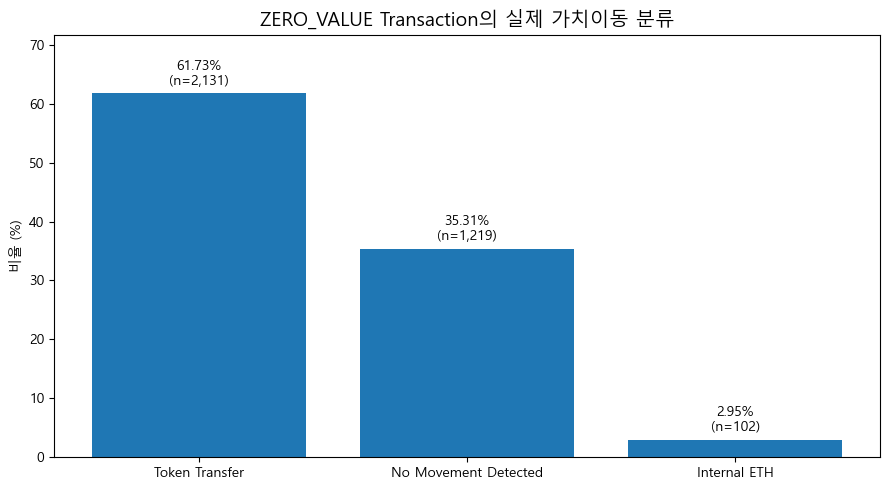

In [27]:
# 16. ZERO_VALUE Transaction 실행 유형 시각화

import matplotlib.pyplot as plt

plot_df = final_summary.copy()

label_map = {
    "TOKEN_TRANSFER": "Token Transfer",
    "INTERNAL_ETH": "Internal ETH",
    "NO_VALUE_MOVEMENT_DETECTED": "No Movement Detected"
}

plot_df["label"] = (
    plot_df["execution_class"]
    .map(label_map)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_df["label"],
    plot_df["ratio"] * 100
)

plt.title(
    "ZERO_VALUE Transaction의 실제 가치이동 분류",
    fontsize=14
)

plt.ylabel("비율 (%)")
plt.xlabel("")

plt.ylim(
    0,
    plot_df["ratio"].max() * 100 + 10
)

for bar, ratio, count in zip(
    bars,
    plot_df["ratio"],
    plot_df["count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{ratio:.2%}\n(n={count:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 9. FPG 설계 결론

2026-01 ZERO_VALUE 분석대상 3,452건을 원본 실행 Evidence와 연결한 결과,

* 2,131건(61.73%)에서 Token Transfer
* 추가 102건(2.95%)에서 Internal ETH Movement
* 총 2,233건(64.69%)에서 추가 가치이동

이 확인되었다.

또한 3,452건 전체가 Receipt와 연결되었으며,
Receipt Status는 성공 3,364건, 실패 88건으로 확인되었다.

따라서 다음 두 명제는 구분되어야 한다.

`Transaction Record ≠ Execution Result`

`Transaction Value ≠ Total Asset Movement`

Transaction의 생성·기록 여부만으로 실행 성공을 판정할 수 없으며,
Transaction의 직접 ETH `value`만으로 실제 가치이동 여부도 판정할 수 없다.

따라서 FPG의 Digital Asset POST_EXECUTION 검증은 동일 Transaction Hash를 기준으로 다음 Evidence를 Binding해야 한다.

`Transaction → Receipt → Trace / Token Transfer → Final Execution State`

각 Evidence의 역할은 다음과 같다.

* Transaction: 온체인 Transaction 식별 및 직접 ETH value
* Receipt: 실제 실행 성공·실패 결과
* Trace: EVM 내부 실행 및 Internal ETH Movement
* Token Transfer: ERC 계열 Token Asset Movement

결론적으로 FPG는 Transaction 제출 또는 기록 자체를 실행 완료로 취급하지 않고,
Receipt 기반 Execution Result와 Trace / Token Transfer 기반 Asset Movement를 함께 확인한 후
최종 실행 상태를 확정해야 한다.


## 11. 한계

본 분석은 Ethereum Master Sample 73,410건 전체가 아니라,
ZERO_VALUE Transaction이 가장 많았던 2026-01의 3,452건을 대상으로 수행하였다.

따라서 확인된 64.69%는 Ethereum 전체 ZERO_VALUE Transaction의 모집단 비율이 아니라,
본 DA-03 분석대상에서 관측된 결과로 해석한다.

# DA-03 최종 요약

DA-03에서는 Ethereum Transaction을 Receipt, Trace, Token Transfer와 연결하여
Transaction 단일 레코드만으로 실제 실행 결과와 가치이동을 판단할 수 있는지 검증하였다.

Ethereum Master Sample 73,410건 중 ZERO_VALUE Transaction은 44,422건이었으며,
DA-03에서는 이 중 2026-01 ZERO_VALUE Transaction 3,452건을 분석하였다.

3,452건의 Transaction Hash를 원본 BigQuery 실행 Evidence와 연결한 결과,

* Receipt Binding: 3,452 / 3,452건 (100%)
* Receipt 성공: 3,364건
* Receipt 실패: 88건
* Token Transfer: 2,131건 (61.73%)
* Token 미확인 거래 중 Internal ETH Movement: 102건
* 추가 가치이동 확인: 총 2,233건 (64.69%)
* Token Transfer 및 Internal ETH Movement 모두 미확인: 1,219건 (35.31%)

이 결과는 두 가지를 보여준다.

첫째,

`Transaction Record ≠ Execution Result`

Transaction이 기록되었다는 사실만으로 실제 실행 성공을 판단할 수 없다.

둘째,

`Transaction Value ≠ Total Asset Movement`

Transaction의 직접 ETH `value = 0`이어도
Token Transfer 또는 Internal ETH Movement를 통해 실제 가치이동이 발생할 수 있다.

따라서 FPG의 Digital Asset 외부 실행 검증은 Transaction 단일 레코드가 아니라

`Transaction → Receipt → Trace / Token Transfer → Final Execution State`

형태의 Evidence Chain을 기준으로 수행해야 한다.

### 최종 설계 반영

**Digital Asset POST_EXECUTION 단계에서는 Transaction Hash를 기준으로
Transaction Record, Receipt Execution Result, Trace / Token Transfer Asset Movement를 Binding하고,
해당 Evidence가 확인된 이후에만 Final Execution State를 확정한다.**
